# 🧪 Notebook 03 — Experiments (Essayage de tous les modèles)
**Projet :** Cervical Cancer Risk Prediction  
**Auteure :** Hadil Dhaya · 4th Year Data Science · Group 5

---
**Objectifs :**
- Tester **7 modèles** de classification
- Comparer via AUC-ROC, F1, Recall, Precision, Accuracy
- Cross-validation 5-fold stratifiée
- Identifier le meilleur modèle
- Tuning des hyperparamètres du meilleur
- Sauvegarder le meilleur modèle

> ⚠️ Ce notebook est le **cahier d'expériences** — toutes les tentatives y sont.

✅ Imports OK
BASE_DIR: C:\Users\GIGABYTE\Desktop\Project-Machine-Learning-
DATA_PATH: C:\Users\GIGABYTE\Desktop\Project-Machine-Learning-\data\Mydata.csv
OUTPUTS_DIR: C:\Users\GIGABYTE\Desktop\Project-Machine-Learning-\outputs
✅ Final features: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)']
Original shape: (300, 10)
Working shape : (298, 10)
Dropped duplicates: 2
Class distribution:
Biopsy
0    150
1    148
Name: count, dtype: int64
Positive rate: 0.4966


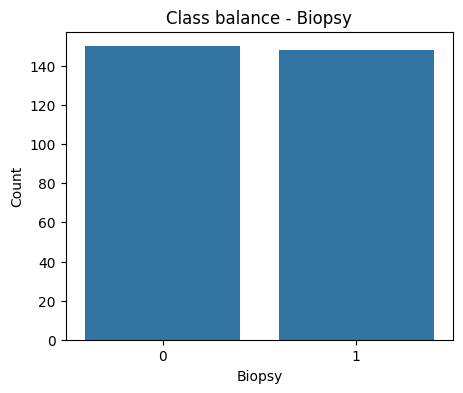

X_train : (238, 9) | y_train : {0: np.int64(120), 1: np.int64(118)}
X_test  : (60, 9) | y_test  : {0: np.int64(30), 1: np.int64(30)}
✅ Preprocessor ready
✅ 7 modèles définis
⏳ Logistic Regression...
  ✅ Test AUC=0.4000 | PR-AUC=0.4672 | Recall=0.4667
⏳ K-Nearest Neighbors...
  ✅ Test AUC=0.8378 | PR-AUC=0.8878 | Recall=0.8667
⏳ Random Forest...
  ✅ Test AUC=0.8267 | PR-AUC=0.8623 | Recall=0.6667
⏳ SVM (RBF)...
  ✅ Test AUC=0.5633 | PR-AUC=0.6651 | Recall=0.4667
⏳ Gradient Boosting...
  ✅ Test AUC=0.8322 | PR-AUC=0.8497 | Recall=0.6333
⏳ AdaBoost...
  ✅ Test AUC=0.7572 | PR-AUC=0.7930 | Recall=0.6000
⏳ MLP Neural Network...
  ✅ Test AUC=0.4222 | PR-AUC=0.4721 | Recall=0.2333

✅ Tous les modèles entraînés et évalués
  CLASSEMENT DES MODÈLES (par PR-AUC puis Recall)
             Modèle  AUC-ROC  PR-AUC          CV AUC       CV PR-AUC     F1  Recall  Precision  Balanced Accuracy  Accuracy
K-Nearest Neighbors   0.8378  0.8878 0.7880 ± 0.0378 0.7953 ± 0.0641 0.7879  0.8667     0.7222        

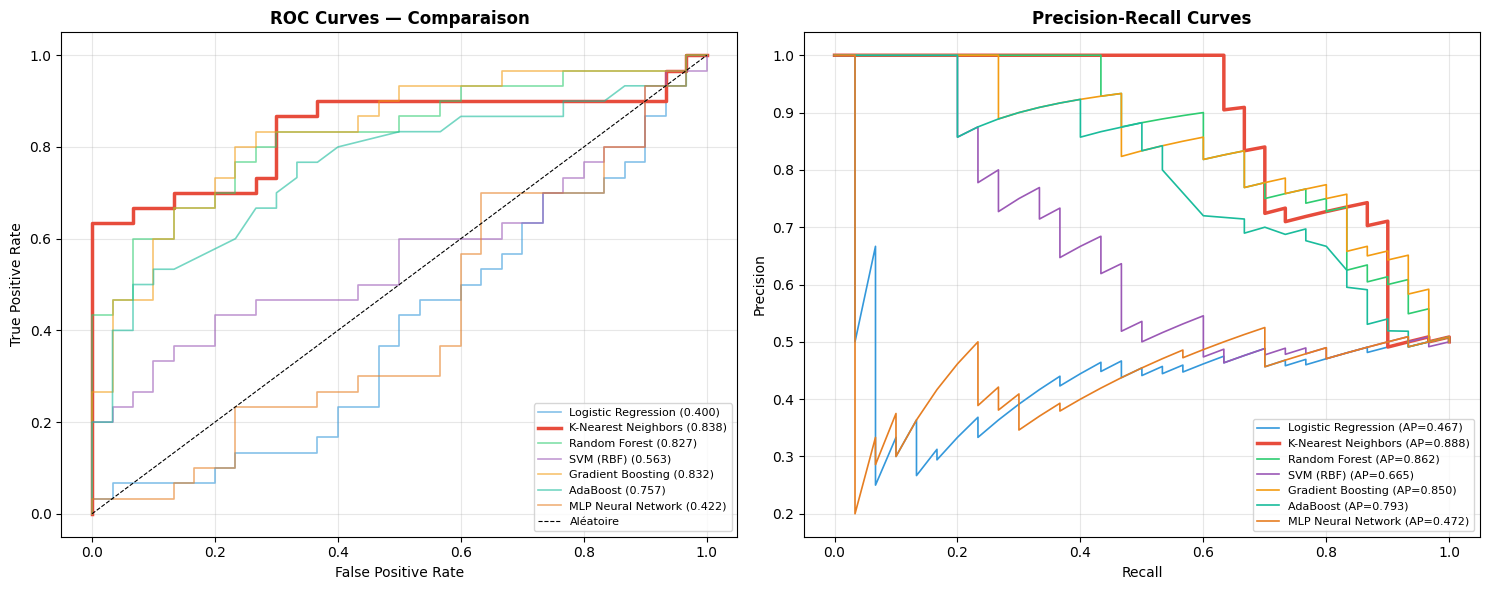

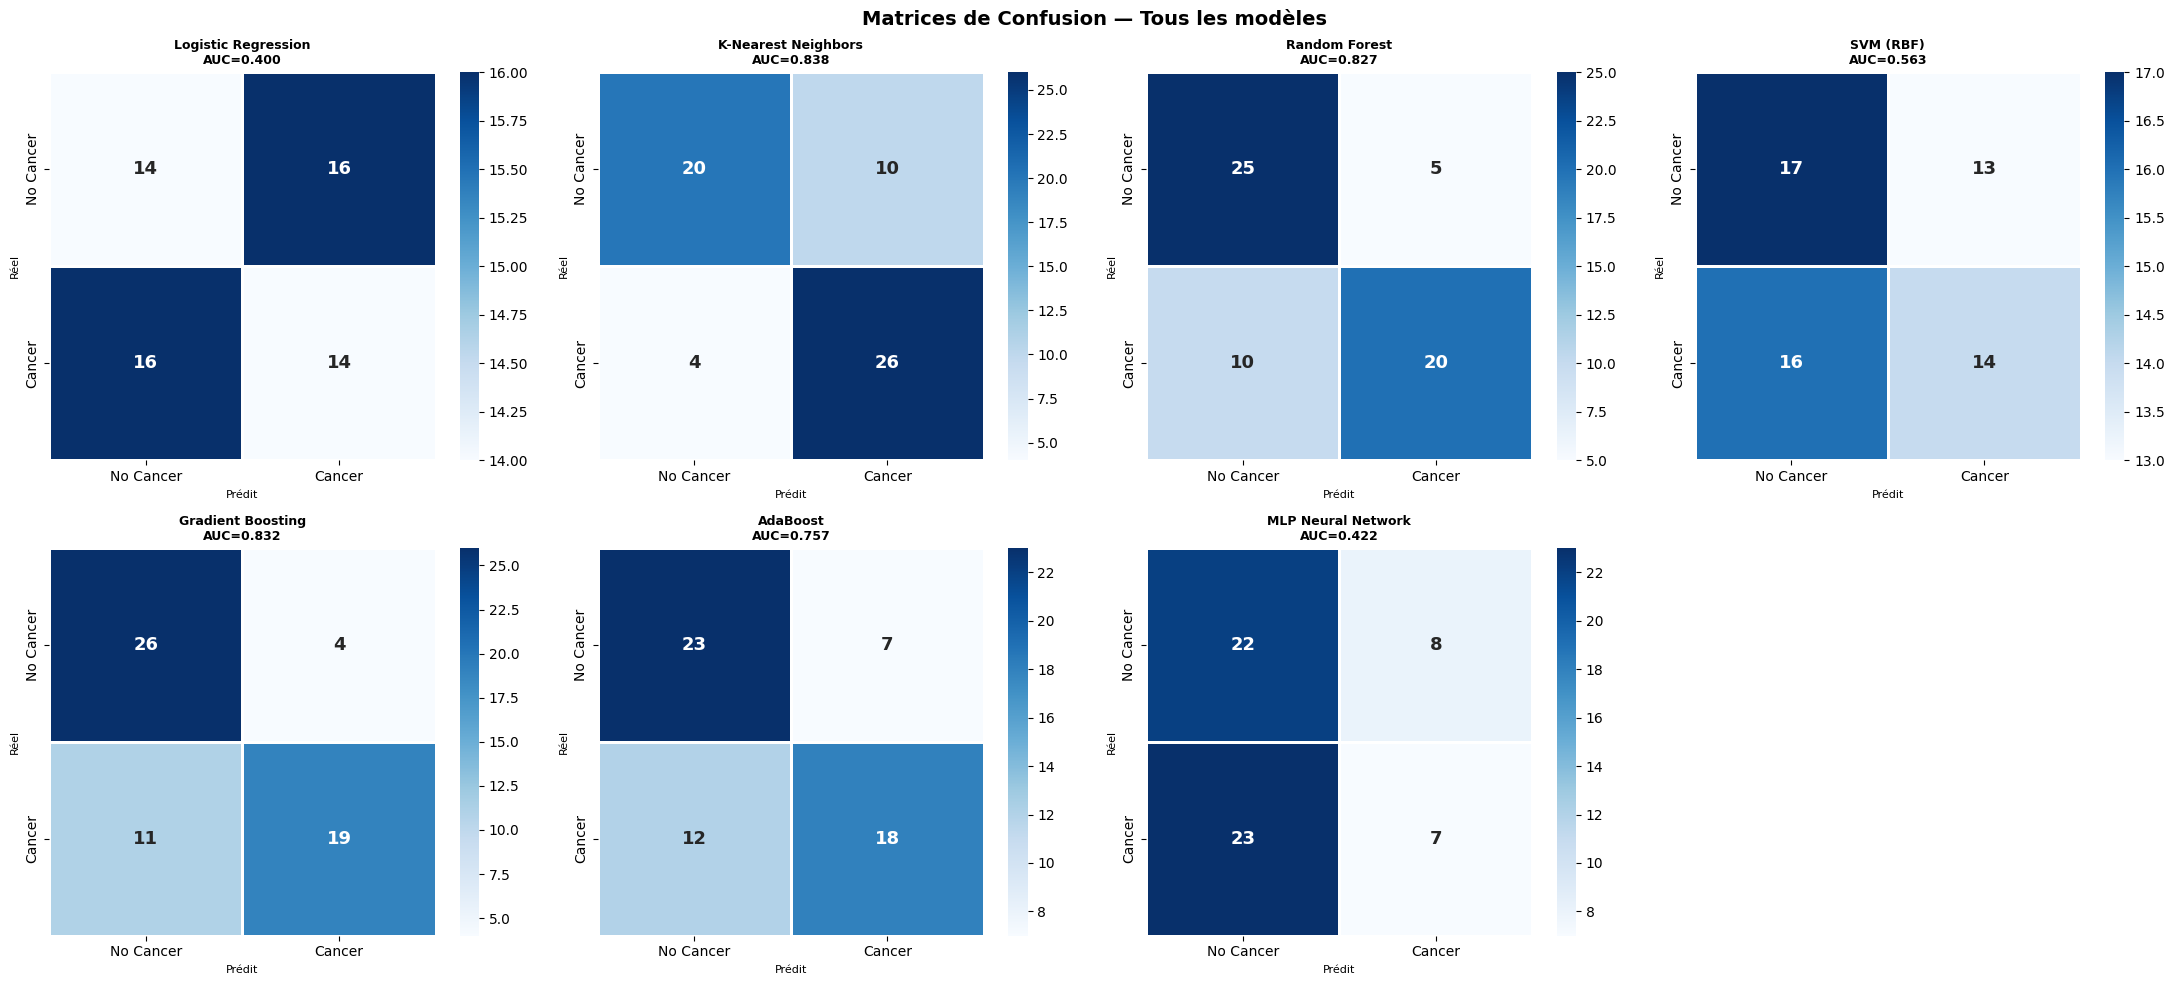

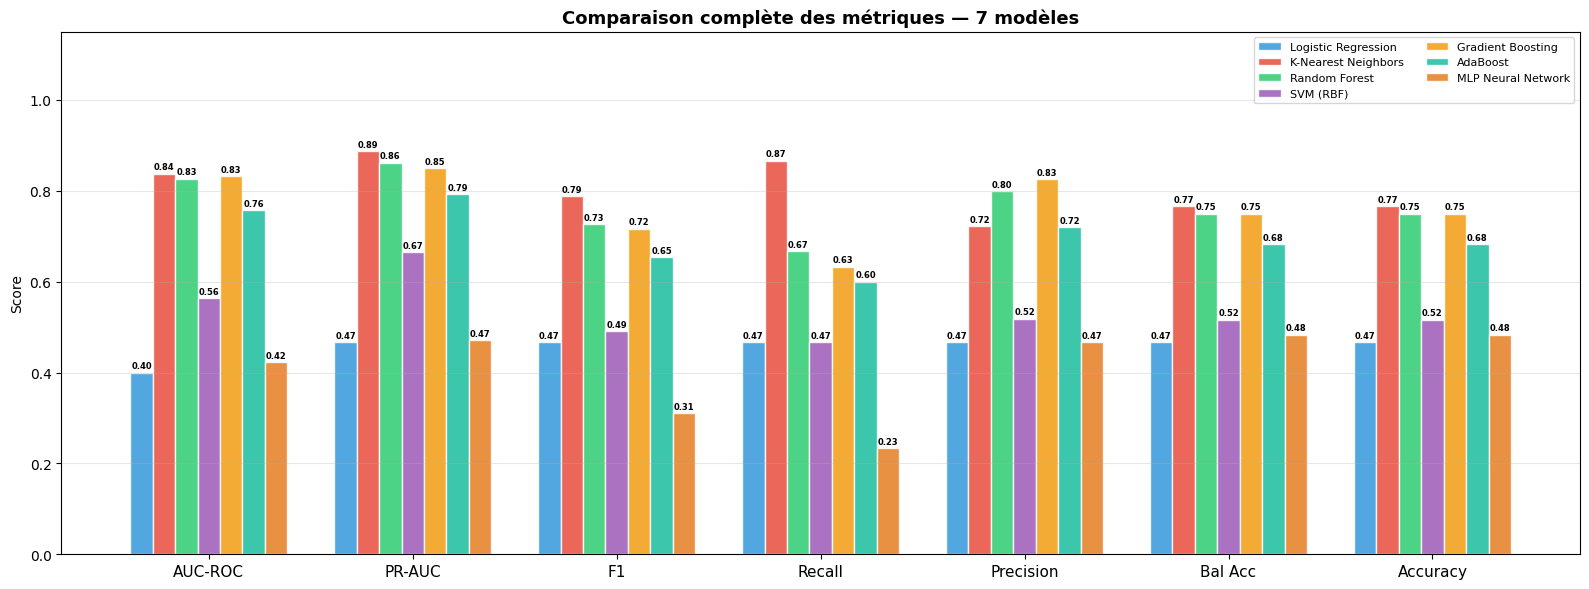

  RAPPORT DÉTAILLÉ — K-Nearest Neighbors
               precision    recall  f1-score   support

No Cancer (0)     0.8333    0.6667    0.7407        30
   Cancer (1)     0.7222    0.8667    0.7879        30

     accuracy                         0.7667        60
    macro avg     0.7778    0.7667    0.7643        60
 weighted avg     0.7778    0.7667    0.7643        60

TP : 26 — cancers détectés
TN : 20 — non-cancers corrects
FP : 10 — fausses alarmes
FN : 4 — cancers manqués
Sensibilité : 0.8667
Spécificité : 0.6667
⏳ RandomizedSearchCV pour K-Nearest Neighbors...

✅ Meilleurs paramètres :
{'model__weights': 'distance', 'model__n_neighbors': 15, 'model__metric': 'minkowski'}

Comparaison avant / après tuning :
  AUC-ROC  avant : 0.8378  →  après : 0.8178
  PR-AUC   avant : 0.8878  →  après : 0.8719
  F1       avant : 0.7879  →  après : 0.7164
  Recall   avant : 0.8667  →  après : 0.8000
✅ Meilleur modèle tuné sauvegardé : K-Nearest Neighbors
✅ Tous les modèles sauvegardés dans outpu

In [1]:

import os
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score,
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = BASE_DIR / "data" / "Mydata.csv"
OUTPUTS_DIR = BASE_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports OK")
print("BASE_DIR:", BASE_DIR)
print("DATA_PATH:", DATA_PATH)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

# %%
TARGET = "Biopsy"

FINAL_FEATURES = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes",
    "Smokes (years)",
    "Smokes (packs/year)",
    "Hormonal Contraceptives",
    "Hormonal Contraceptives (years)",
]

print("✅ Final features:", FINAL_FEATURES)

# %%
df = pd.read_csv(DATA_PATH, na_values="?")

missing_features = [c for c in FINAL_FEATURES if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing expected features in CSV: {missing_features}")

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found")

work_df = df[FINAL_FEATURES + [TARGET]].copy()

before = len(work_df)
work_df = work_df.drop_duplicates().reset_index(drop=True)
after = len(work_df)

print("Original shape:", df.shape)
print("Working shape :", work_df.shape)
print("Dropped duplicates:", before - after)
work_df.head()

# %%
X = work_df[FINAL_FEATURES].copy()
y = work_df[TARGET].astype(int)

print("Class distribution:")
print(y.value_counts().sort_index())
print("Positive rate:", round(float(y.mean()), 4))

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Class balance - Biopsy")
plt.xlabel("Biopsy")
plt.ylabel("Count")
plt.show()

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f"X_train : {X_train.shape} | y_train : {dict(y_train.value_counts())}")
print(f"X_test  : {X_test.shape} | y_test  : {dict(y_test.value_counts())}")

# %%
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, FINAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("✅ Preprocessor ready")

# %%
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=9,
        weights="distance"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=1200,
        random_state=42,
        early_stopping=True
    ),
}

print(f"✅ {len(models)} modèles définis")

# %%
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
}

# %%
results = {}

for name, model in models.items():
    print(f"⏳ {name}...")

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "ap": average_precision_score(y_test, y_prob),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "cv_auc": cv_result["test_roc_auc"].mean(),
        "cv_auc_std": cv_result["test_roc_auc"].std(),
        "cv_ap": cv_result["test_pr_auc"].mean(),
        "cv_ap_std": cv_result["test_pr_auc"].std(),
        "cv_recall": cv_result["test_recall"].mean(),
        "cv_recall_std": cv_result["test_recall"].std(),
        "cm": confusion_matrix(y_test, y_pred),
        "fpr": fpr,
        "tpr": tpr,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
    }

    print(
        f"  ✅ Test AUC={results[name]['auc']:.4f} | "
        f"PR-AUC={results[name]['ap']:.4f} | "
        f"Recall={results[name]['recall']:.4f}"
    )

print("\n✅ Tous les modèles entraînés et évalués")

# %%
rows = []
for name, r in results.items():
    rows.append({
        "Modèle": name,
        "AUC-ROC": round(r["auc"], 4),
        "PR-AUC": round(r["ap"], 4),
        "CV AUC": f"{r['cv_auc']:.4f} ± {r['cv_auc_std']:.4f}",
        "CV PR-AUC": f"{r['cv_ap']:.4f} ± {r['cv_ap_std']:.4f}",
        "F1": round(r["f1"], 4),
        "Recall": round(r["recall"], 4),
        "Precision": round(r["precision"], 4),
        "Balanced Accuracy": round(r["balanced_accuracy"], 4),
        "Accuracy": round(r["accuracy"], 4),
    })

df_res = pd.DataFrame(rows).sort_values(
    by=["PR-AUC", "Recall", "AUC-ROC"],
    ascending=False
).reset_index(drop=True)

print("=" * 95)
print("  CLASSEMENT DES MODÈLES (par PR-AUC puis Recall)")
print("=" * 95)
print(df_res.to_string(index=False))
print("=" * 95)

best_name = df_res.iloc[0]["Modèle"]
print(f"\n🏆 Meilleur modèle sélectionné : {best_name}")

# %%
colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c", "#e67e22"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for (name, r), c in zip(results.items(), colors):
    lw = 2.5 if name == best_name else 1.2
    al = 1.0 if name == best_name else 0.6
    axes[0].plot(r["fpr"], r["tpr"], color=c, lw=lw, alpha=al, label=f"{name} ({r['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Aléatoire")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Comparaison", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)

for (name, r), c in zip(results.items(), colors):
    lw = 2.5 if name == best_name else 1.2
    axes[1].plot(r["rec_curve"], r["prec_curve"], color=c, lw=lw, label=f"{name} (AP={r['ap']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "roc_pr_curves.png", dpi=150)
plt.show()

# %%
n = len(results)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    sns.heatmap(
        r["cm"],
        annot=True,
        fmt="d",
        ax=axes[i],
        cmap="Blues",
        linewidths=1,
        linecolor="white",
        xticklabels=["No Cancer", "Cancer"],
        yticklabels=["No Cancer", "Cancer"],
        annot_kws={"size": 13, "weight": "bold"}
    )
    auc_str = f"AUC={r['auc']:.3f}"
    axes[i].set_title(f"{name}\n{auc_str}", fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Prédit", fontsize=8)
    axes[i].set_ylabel("Réel", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Matrices de Confusion — Tous les modèles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# %%
metrics_list = ["auc", "ap", "f1", "recall", "precision", "balanced_accuracy", "accuracy"]
labels = ["AUC-ROC", "PR-AUC", "F1", "Recall", "Precision", "Bal Acc", "Accuracy"]

x = np.arange(len(metrics_list))
width = 0.11
colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c", "#e67e22"]

fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold"
        )

ax.set_xticks(x + width * (len(results) - 1) / 2)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Comparaison complète des métriques — 7 modèles", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "metrics_comparison.png", dpi=150)
plt.show()

# %%
best = results[best_name]
tn, fp, fn, tp = best["cm"].ravel()

print("=" * 60)
print(f"  RAPPORT DÉTAILLÉ — {best_name}")
print("=" * 60)
print(classification_report(
    y_test,
    best["y_pred"],
    target_names=["No Cancer (0)", "Cancer (1)"],
    digits=4
))
print(f"TP : {tp} — cancers détectés")
print(f"TN : {tn} — non-cancers corrects")
print(f"FP : {fp} — fausses alarmes")
print(f"FN : {fn} — cancers manqués")
print(f"Sensibilité : {tp/(tp+fn+1e-9):.4f}")
print(f"Spécificité : {tn/(tn+fp+1e-9):.4f}")

# %%
param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 500],
        "model__max_depth": [None, 8, 12, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.7, 0.8, 1.0],
    },
    "SVM (RBF)": {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    },
    "Logistic Regression": {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    },
    "MLP Neural Network": {
        "model__hidden_layer_sizes": [(32,), (64, 32), (128, 64)],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.001, 0.01],
    },
    "AdaBoost": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.1, 0.5, 1.0],
    },
    "K-Nearest Neighbors": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__metric": ["euclidean", "manhattan", "minkowski"],
        "model__weights": ["uniform", "distance"],
    },
}

# %%
if best_name in param_grids:
    print(f"⏳ RandomizedSearchCV pour {best_name}...")

    base_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", models[best_name]),
        ]
    )

    search = RandomizedSearchCV(
        estimator=base_pipe,
        param_distributions=param_grids[best_name],
        n_iter=20,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="average_precision",
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )

    search.fit(X_train, y_train)
    best_tuned = search.best_estimator_

    y_pred_t = best_tuned.predict(X_test)
    y_prob_t = best_tuned.predict_proba(X_test)[:, 1]

    tuned_auc = roc_auc_score(y_test, y_prob_t)
    tuned_ap = average_precision_score(y_test, y_prob_t)
    tuned_f1 = f1_score(y_test, y_pred_t, zero_division=0)
    tuned_rec = recall_score(y_test, y_pred_t, zero_division=0)

    print("\n✅ Meilleurs paramètres :")
    print(search.best_params_)

    print("\nComparaison avant / après tuning :")
    print(f"  AUC-ROC  avant : {results[best_name]['auc']:.4f}  →  après : {tuned_auc:.4f}")
    print(f"  PR-AUC   avant : {results[best_name]['ap']:.4f}  →  après : {tuned_ap:.4f}")
    print(f"  F1       avant : {results[best_name]['f1']:.4f}  →  après : {tuned_f1:.4f}")
    print(f"  Recall   avant : {results[best_name]['recall']:.4f}  →  après : {tuned_rec:.4f}")
else:
    best_tuned = results[best_name]["pipeline"]
    print(f"Pas de grille pour {best_name}, on garde le modèle de base.")

# %%
joblib.dump(best_tuned, OUTPUTS_DIR / "best_model_tuned.pkl")
joblib.dump(best_name, OUTPUTS_DIR / "best_model_name.pkl")

all_models = {name: r["pipeline"] for name, r in results.items()}
joblib.dump(all_models, OUTPUTS_DIR / "all_models.pkl")

experiment_summary = {
    "target": TARGET,
    "final_raw_features": FINAL_FEATURES,
    "best_model_name": best_name,
    "ranking_metric": ["PR-AUC", "Recall", "AUC-ROC"],
    "dataset_used": "Mydata.csv",
}

with open(OUTPUTS_DIR / "experiments_summary.json", "w", encoding="utf-8") as f:
    json.dump(experiment_summary, f, indent=2)

print(f"✅ Meilleur modèle tuné sauvegardé : {best_name}")
print("✅ Tous les modèles sauvegardés dans outputs/all_models.pkl")
print("✅ Résumé sauvegardé : outputs/experiments_summary.json")
print("\n✅ Experiments terminés → lancer 04_Final_Notebook.ipynb")